# Seasonal model comparison

This notebook runs and inspects the seasonal snow-depth comparison between FSM2 and seNorge against SNOWPACK for the 2024/2025 season.

The heavy/reusable functions live in `scripts/seasonal_model_comparison.py`, while this notebook is meant for running the workflow, checking outputs, and interpreting the results.

## Setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.seasonal_model_comparison import (
    PROCESSED,
    main as run_seasonal_analysis,
)

pd.set_option("display.max_columns", 50)
PROJECT_ROOT, PROCESSED

(PosixPath('/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models'),
 PosixPath('/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models/data/processed'))

## Run analysis

Run this cell when you want to regenerate the seasonal metrics and figures. It processes all 4484 SNOWPACK station points in batches.

In [2]:
run_seasonal_analysis()

Loading SNOWPACK data...
Computing seasonal station metrics and daily error evolution...
Processing stations 1-250 of 4484...
Processing stations 251-500 of 4484...
Processing stations 501-750 of 4484...
Processing stations 751-1000 of 4484...
Processing stations 1001-1250 of 4484...
Processing stations 1251-1500 of 4484...
Processing stations 1501-1750 of 4484...
Processing stations 1751-2000 of 4484...
Processing stations 2001-2250 of 4484...
Processing stations 2251-2500 of 4484...
Processing stations 2501-2750 of 4484...
Processing stations 2751-3000 of 4484...
Processing stations 3001-3250 of 4484...
Processing stations 3251-3500 of 4484...
Processing stations 3501-3750 of 4484...
Processing stations 3751-4000 of 4484...
Processing stations 4001-4250 of 4484...
Processing stations 4251-4484 of 4484...
Creating figures...

Saved outputs:
- data/processed/seasonal_model_metrics.csv
- data/processed/seasonal_model_metrics_long.csv
- data/processed/seasonal_model_summary.csv
- data/pr

## Load generated outputs

In [3]:
seasonal_metrics = pd.read_csv(PROCESSED / "seasonal_model_metrics.csv")
seasonal_metrics_long = pd.read_csv(PROCESSED / "seasonal_model_metrics_long.csv")
seasonal_summary = pd.read_csv(PROCESSED / "seasonal_model_summary.csv")
daily_errors = pd.read_csv(PROCESSED / "seasonal_daily_error_evolution.csv", parse_dates=["time"])

print("seasonal_metrics:", seasonal_metrics.shape)
print("seasonal_metrics_long:", seasonal_metrics_long.shape)
print("seasonal_summary:", seasonal_summary.shape)
print("daily_errors:", daily_errors.shape)

seasonal_metrics: (17936, 18)
seasonal_metrics_long: (35872, 15)
seasonal_summary: (8, 13)
daily_errors: (548, 7)


## Seasonal summary

In [4]:
seasonal_summary.round(3)

,season,season_label,model,n_stations,mean_bias,median_bias,mean_abs_bias,mean_rmse,median_rmse,mean_corr,median_corr
0,early,Early season,FSM2,4484,0.137,0.115,0.141,0.207,0.187,0.979,0.986
1,early,Early season,seNorge,4484,0.095,0.061,0.135,0.201,0.147,0.953,0.966
2,midwinter,Mid-winter,FSM2,4476,0.247,0.280,0.318,0.360,0.333,0.870,0.921
3,midwinter,Mid-winter,seNorge,4476,0.058,0.046,0.380,0.409,0.318,0.895,0.963
4,melt,Melt season,FSM2,4476,-0.079,-0.042,0.204,0.251,0.187,0.919,0.973
5,melt,Melt season,seNorge,4476,0.091,0.050,0.455,0.508,0.367,0.907,0.959
6,full,Full season,FSM2,4484,0.124,0.128,0.176,0.295,0.281,0.949,0.968
7,full,Full season,seNorge,4484,0.082,0.063,0.275,0.376,0.289,0.943,0.972


## Best model counts

In [5]:
best_rmse_counts = seasonal_metrics.groupby(["season_label", "best_model_rmse"]).size().unstack(fill_value=0)
best_bias_counts = seasonal_metrics.groupby(["season_label", "best_model_abs_bias"]).size().unstack(fill_value=0)

print("Best model by RMSE")
display(best_rmse_counts)

print("Best model by absolute bias")
display(best_bias_counts)

Best model by RMSE


best_model_rmse,FSM2,Tie,seNorge
season_label,,,
Early season,1978,3,2503
Full season,2577,3,1904
Melt season,3292,166,1026
Mid-winter,2383,8,2093


Best model by absolute bias


best_model_abs_bias,FSM2,Tie,seNorge
season_label,,,
Early season,1971,3,2510
Full season,2829,3,1652
Melt season,3172,166,1146
Mid-winter,2472,8,2004


## Figure 09: Seasonal performance distributions

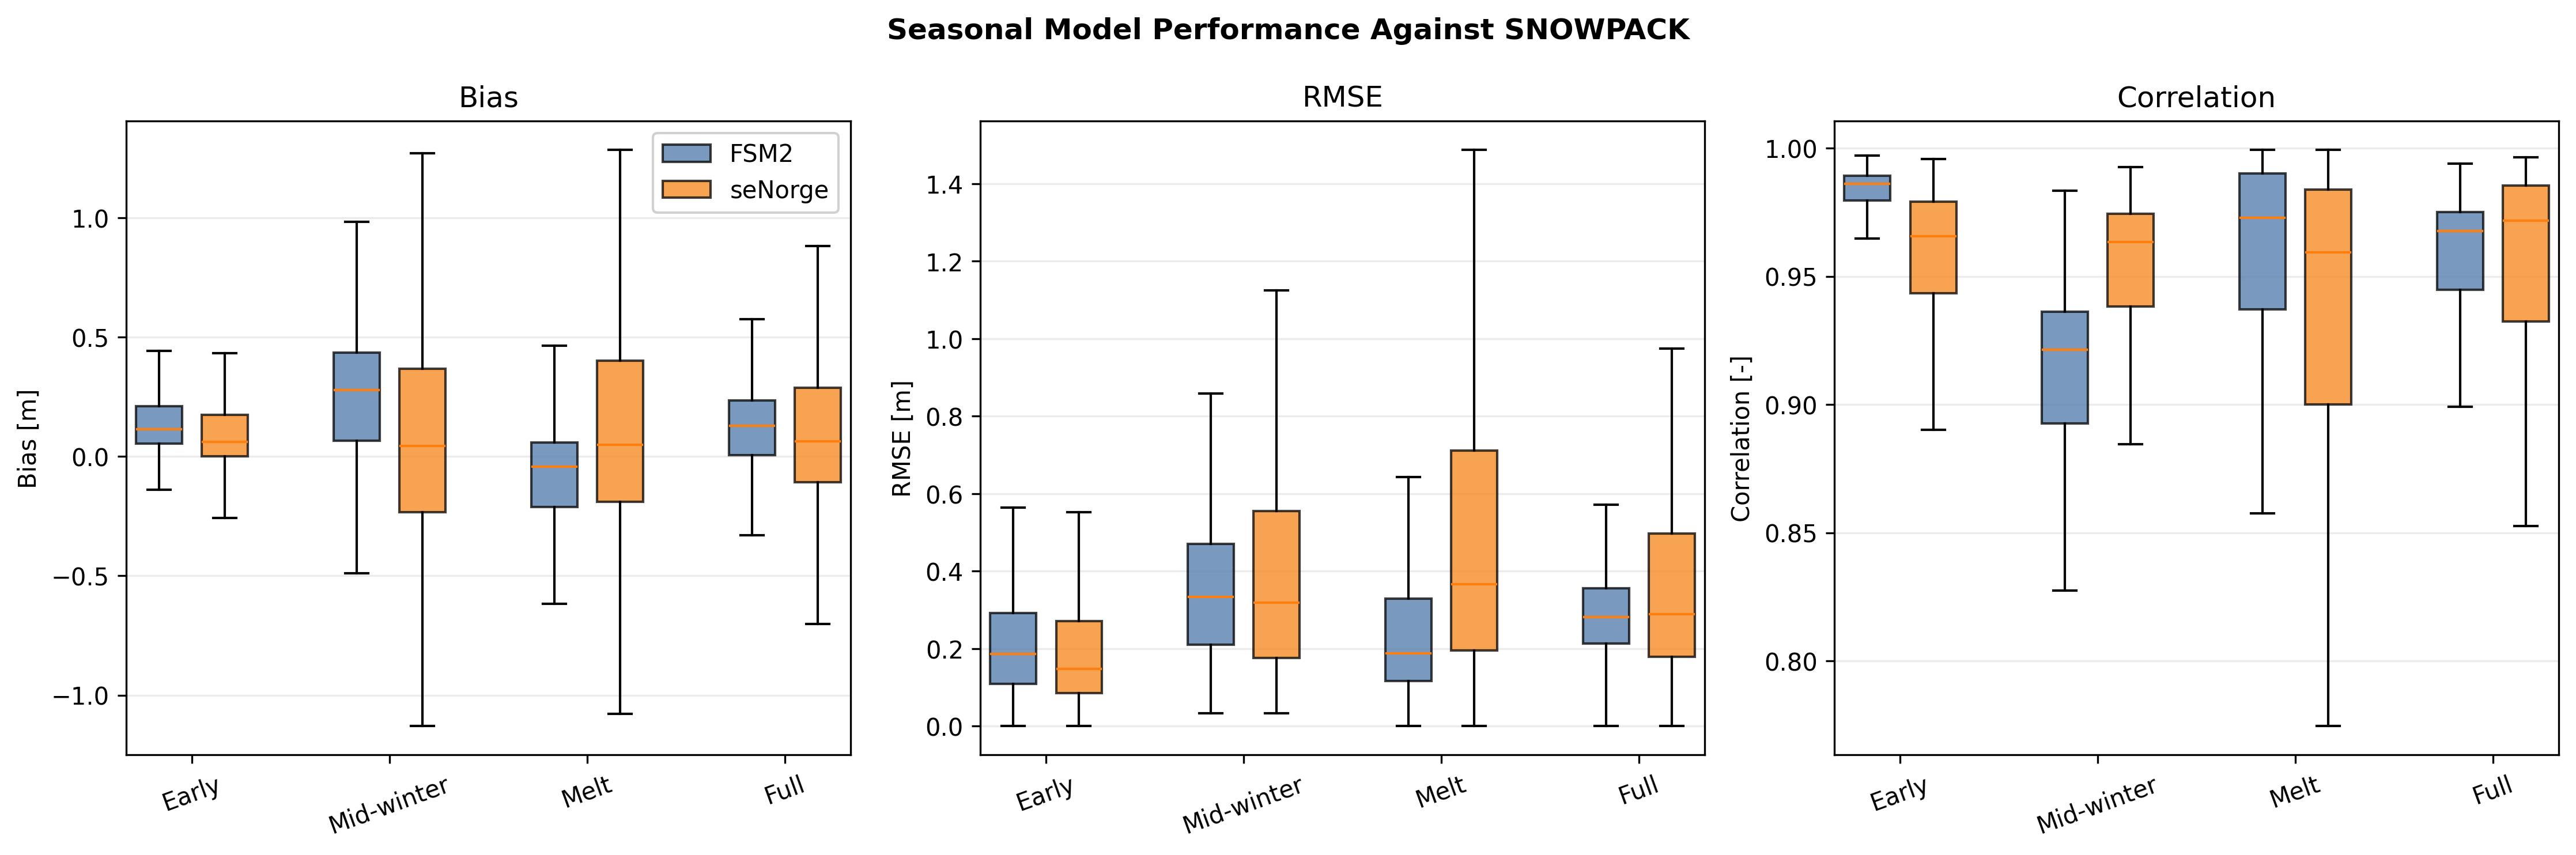

In [6]:
display(Image(filename=PROCESSED / "Figure_09_Seasonal_Model_Performance.png"))

## Figure 10: Spatial RMSE difference by season

Positive values mean that seNorge has higher RMSE than FSM2, so FSM2 performs better. Negative values mean seNorge performs better.

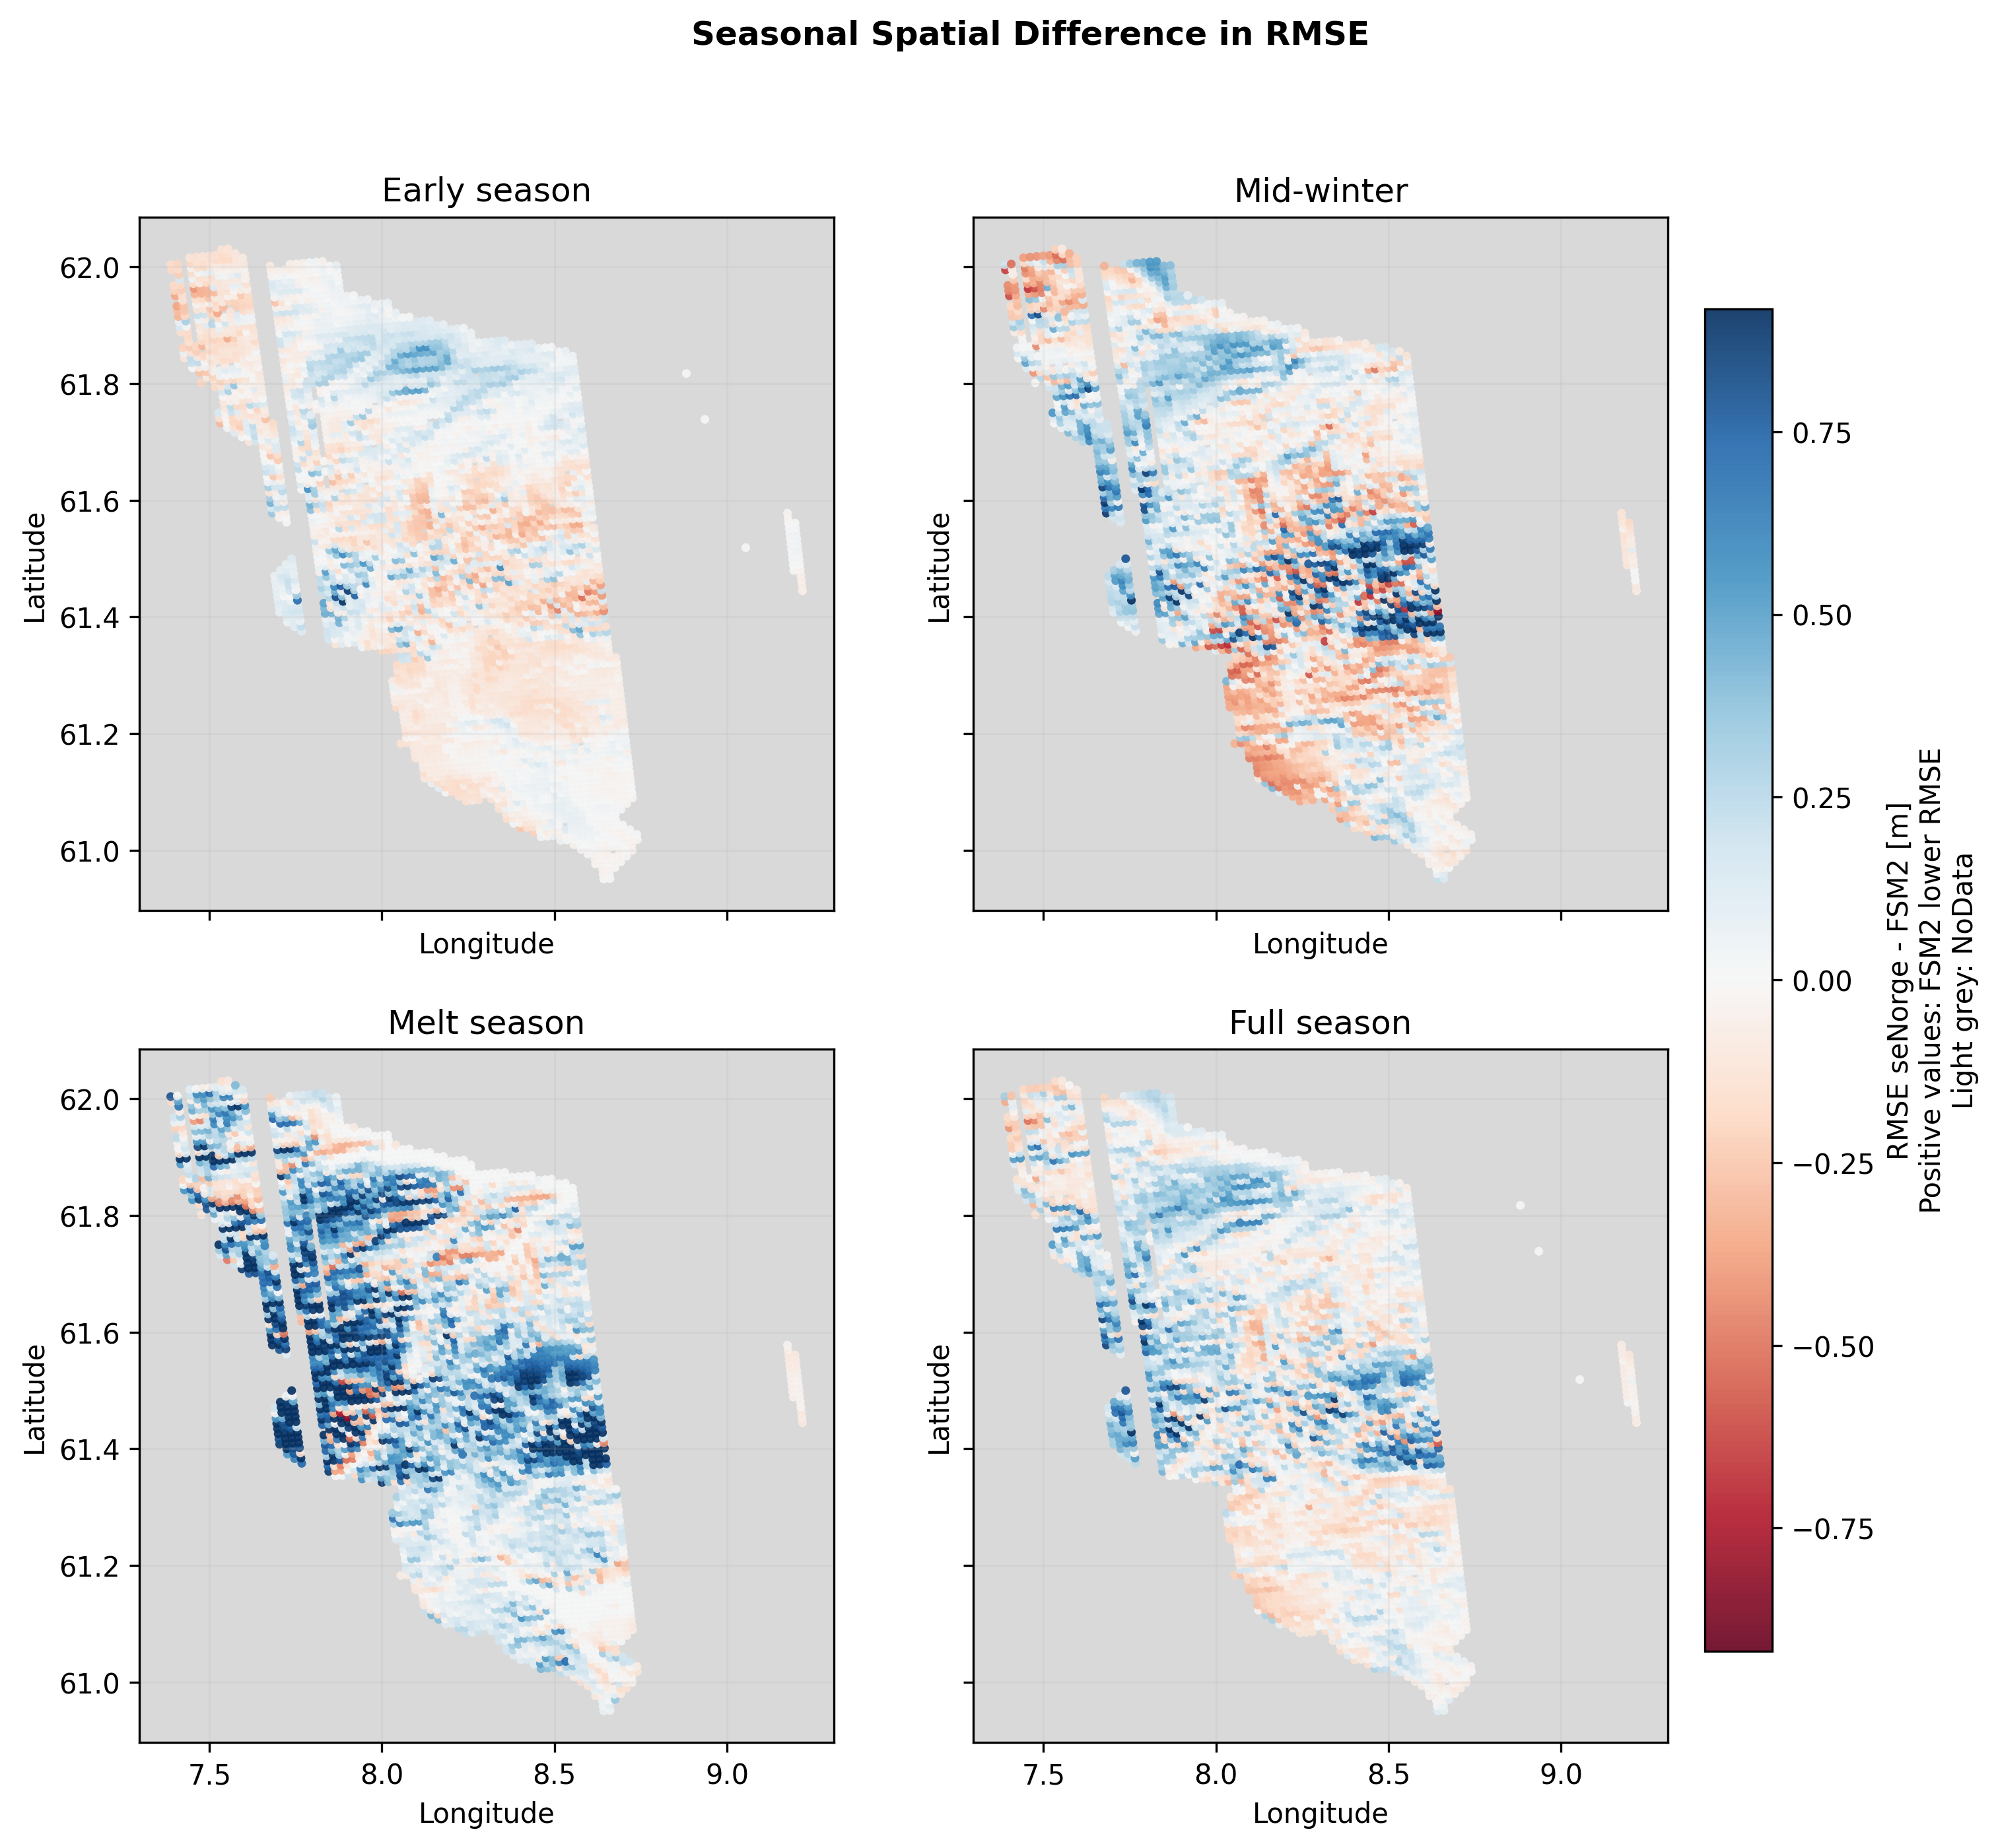

In [7]:
display(Image(filename=PROCESSED / "Figure_10_Seasonal_RMSE_Difference_Maps.png"))

## Figure 11: Daily error evolution

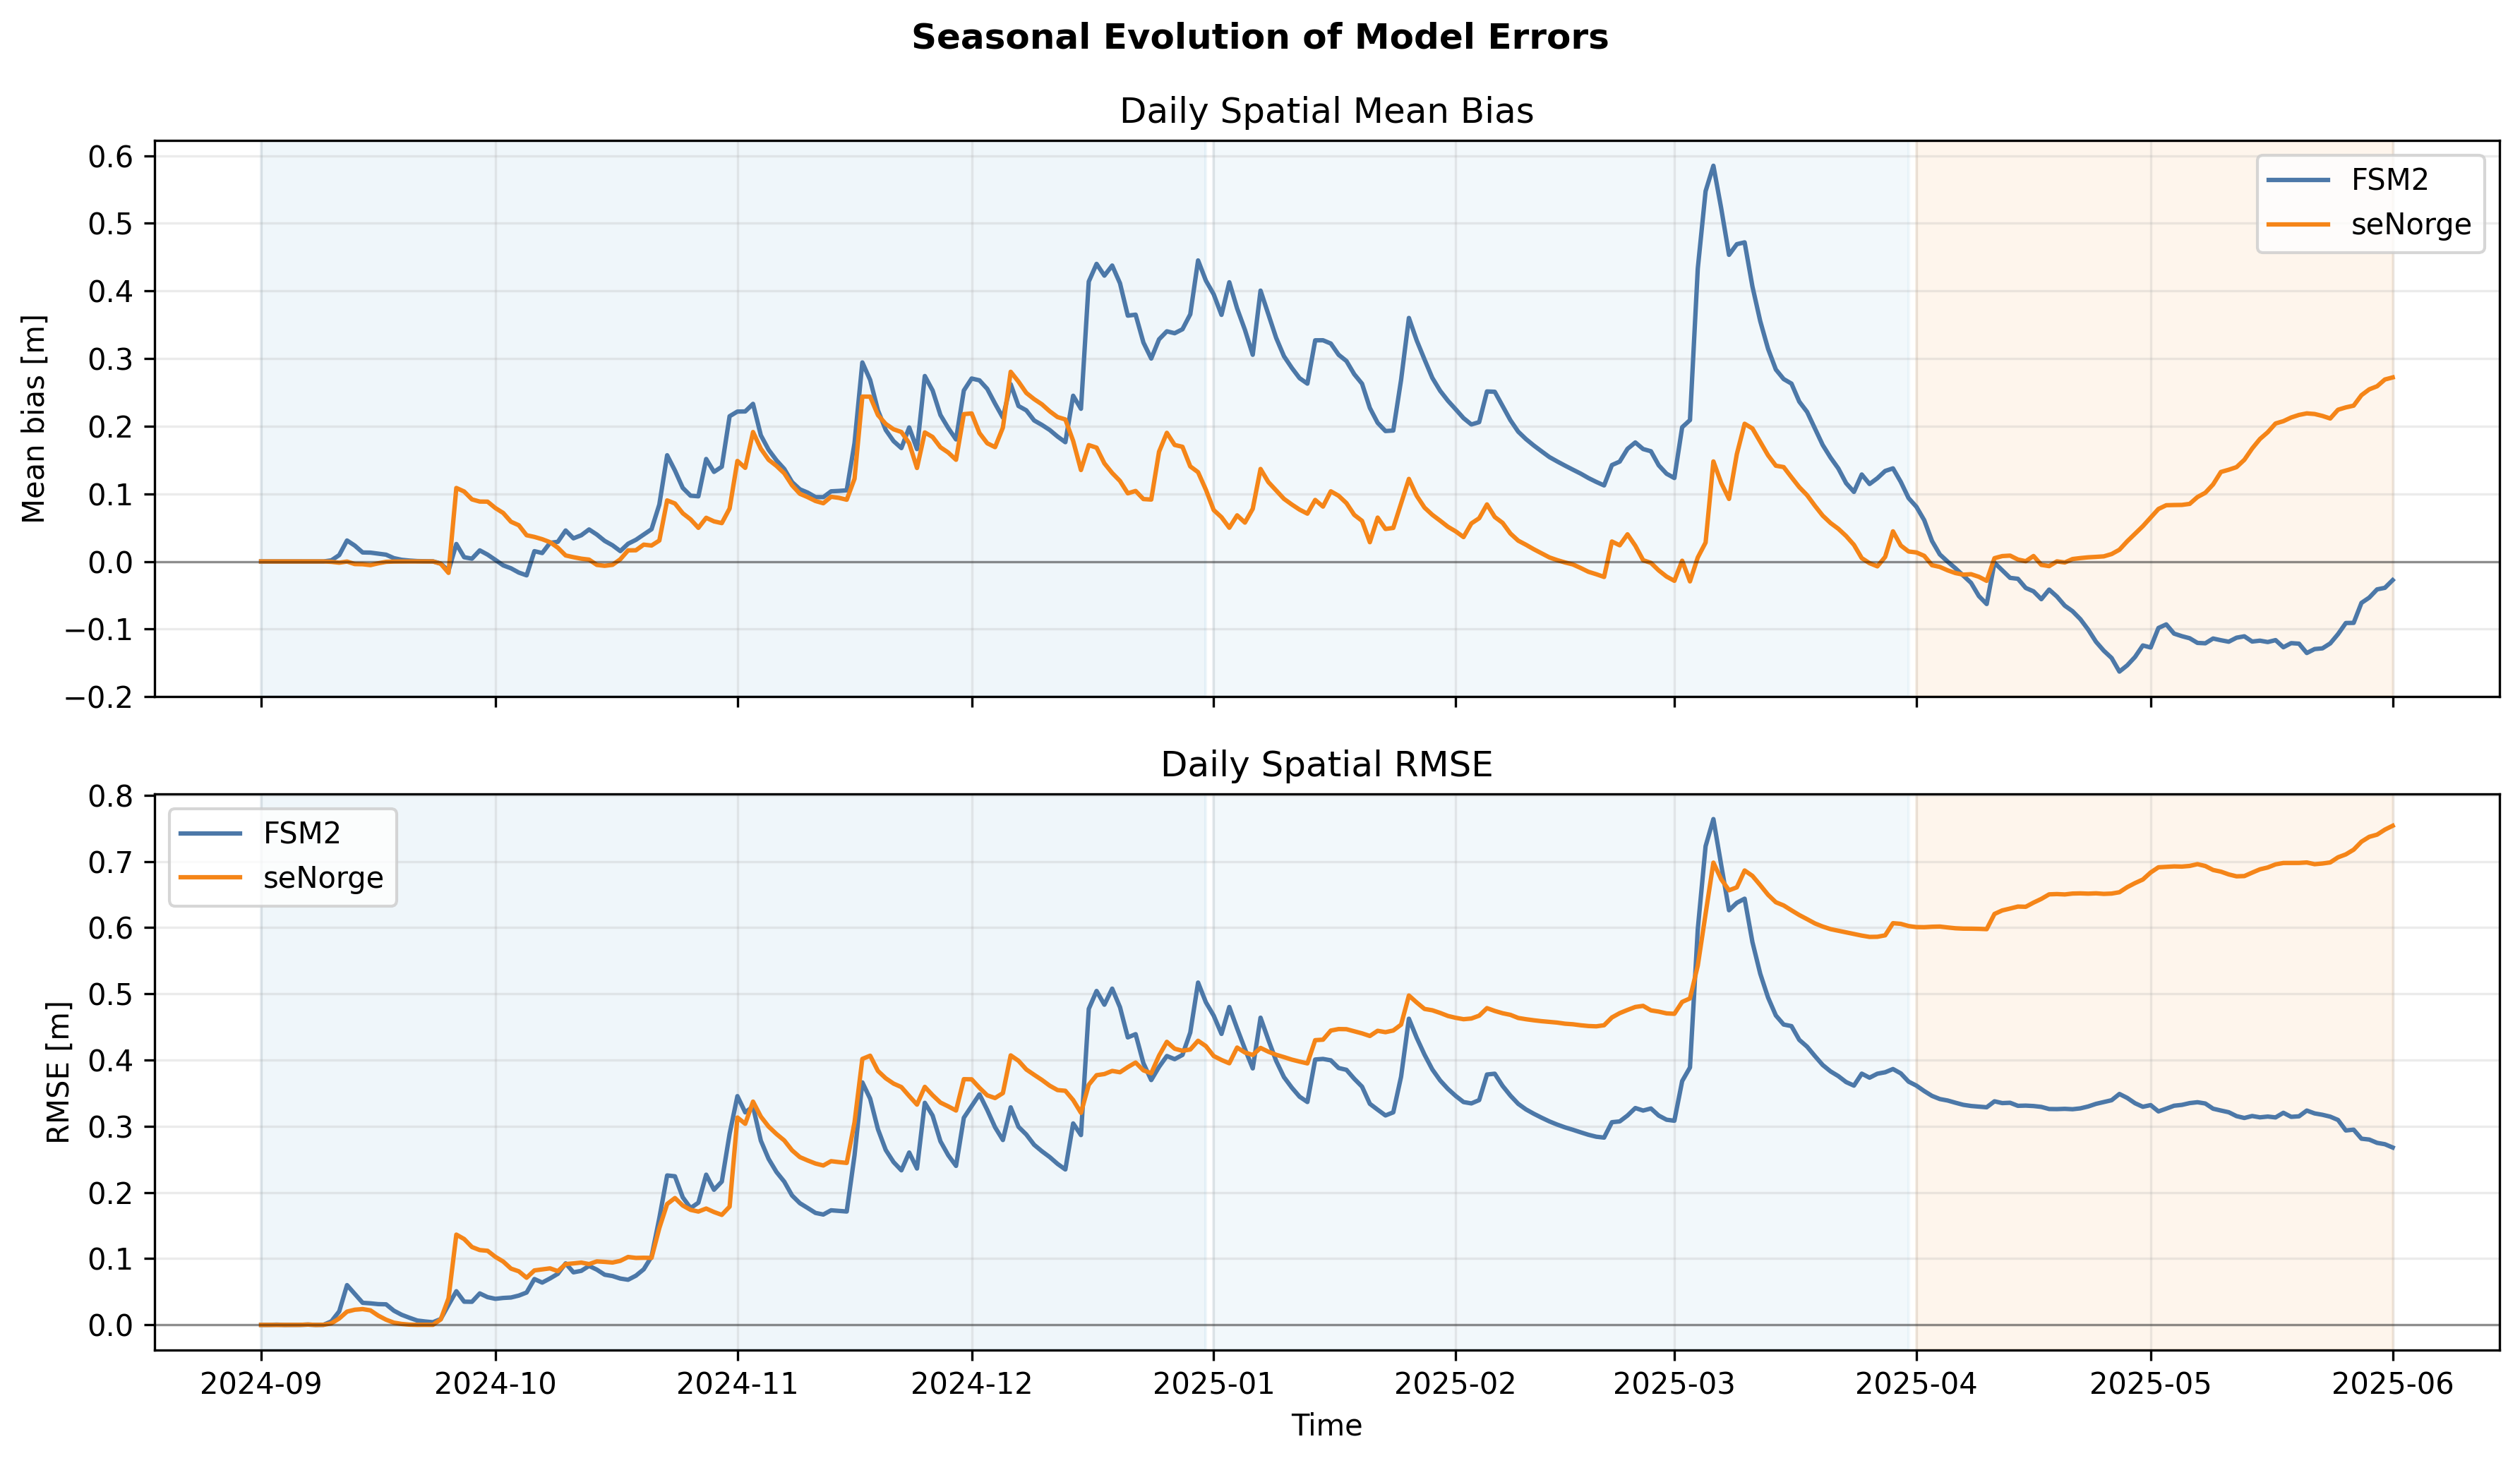

In [8]:
display(Image(filename=PROCESSED / "Figure_11_Seasonal_Error_Evolution.png"))

## Quick interpretation notes

- Early season: FSM2 and seNorge are relatively similar, with seNorge slightly lower mean RMSE in the current summary.
- Mid-winter: FSM2 has lower mean RMSE, while seNorge has slightly lower median RMSE and higher median correlation.
- Melt season: FSM2 clearly has lower mean and median RMSE, suggesting that model differences are largest during snowmelt.
- Full season: FSM2 has lower mean RMSE overall, while median RMSE is close between the models.

Use these notes as starting points only; the spatial maps should be used to describe where the seasonal differences are strongest.